<a href="https://colab.research.google.com/github/cysorianoc/IBM_Machine_Learning/blob/main/Course_1_ML_NB_3_Data_Cleaning_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# Data Cleaning

Estimated time needed: **45** minutes

Most of the real-world data, that the data scientist work with, are raw data, meaning that it can contain repeated, missing, and irrelevant entries of information. Hence, if this data is used in any machine learning analysis, it will result in low accuracy or incorrect prediction. For this reason, data cleaning, also known as data cleansing, is an important technique that comes prior to any model building.

In this notebook, we will take a look at some of the common data cleaning techniques that data scientists may use to prepare their data for analysis.

## Objectives

After completing this lab you will be able to:

*   Use Log function to transform the data
*   Handle the duplicates
*   Handle the missing values
*   Standardize and normalize the data
*   Handle the outliers



***


## **Setup**


For this lab, we will be using the following libraries:
 - [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) for managing the data.
 - [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) for mathematical operations.
 - [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) for visualizing the data.
 - [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) for visualizing the data.
 - [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) for machine learning and machine-learning-pipeline related functions.
 - [`scipy`](https://docs.scipy.org/doc/scipy/tutorial/stats.html/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) for statistical computations.


## **Import the required libraries**


The following required modules are pre-installed in the Skills Network Labs environment. However if you run this notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda) you will need to install these libraries by removing the `#` sign before `!mamba` in the code cell below.


In [ ]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from scipy.stats import norm
from scipy import stats

## **Reading and understanding our data**


For this lab, we will be using the Ames_Housing_Data.tsv file, hosted on IBM Cloud object storage. The Ames housing dataset examines features of houses sold in Ames (a small city in the state of Iowa in the United States) during the 2006–2010 timeframe.


Let's read the data into *pandas* data frame and look at the first 5 rows using the `head()` method.


In [ ]:
housing = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0232EN-SkillsNetwork/asset/Ames_Housing_Data1.tsv", sep='\t')
housing.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
6,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
7,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
8,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
9,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500


We can find more information about the features and types using the `info()`  method.


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2931 non-null   int64  
 1   PID              2931 non-null   int64  
 2   MS SubClass      2931 non-null   int64  
 3   MS Zoning        2931 non-null   object 
 4   Lot Frontage     2441 non-null   float64
 5   Lot Area         2931 non-null   int64  
 6   Street           2931 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2931 non-null   object 
 9   Land Contour     2931 non-null   object 
 10  Utilities        2931 non-null   object 
 11  Lot Config       2931 non-null   object 
 12  Land Slope       2931 non-null   object 
 13  Neighborhood     2931 non-null   object 
 14  Condition 1      2931 non-null   object 
 15  Condition 2      2931 non-null   object 
 16  Bldg Type        2931 non-null   object 
 17  House Style   

According to the output above, we have 2930 entries, 0 to 2929, as well as 81 features. The "Non-Null Count" column shows the number of non-null entries.  If the count is 2930 then there is no missing values for that particular feature. 'SalePrice' is our target or response variable and the rest of the features are our predictor variables.

We also have a mix of numerical (28 int64 and 11 float64) and object data types.


Next, let's use the `describe()` function to show the count, mean, min, max of the sale price attribute.


In [ ]:
housing["SalePrice"].describe()

,SalePrice
count,2931.000000
mean,180807.729785
std,79875.557267
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


From the above analysis, it is important to note that the minimum value is greater than 0. Also, there is a big difference between the minimum value and the 25th percentile. It is bigger than the 75th percentile and the maximum value. This means that our data might not be normally distributed (an important assumption for linear regression analysis), so will check for normality in the Log Transform section.


## Exercise 1


The `describe()` function reveals the statistical information about the numeric attributes. To reveal some information about our categorical (object) attributes, we can use `value_counts()` function. In this exercise, describe all categories of the 'Sale Condition' attribute.


In [ ]:
housing['Sale Condition'].value_counts()

,count
Sale Condition,
Normal,2414
Partial,245
Abnorml,190
Family,46
Alloca,24
AdjLand,12


In [ ]:
# another example with roof style
housing['Roof Style'].value_counts()

,count
Roof Style,
Gable,2321
Hip,552
Gambrel,22
Flat,20
Mansard,11
Shed,5


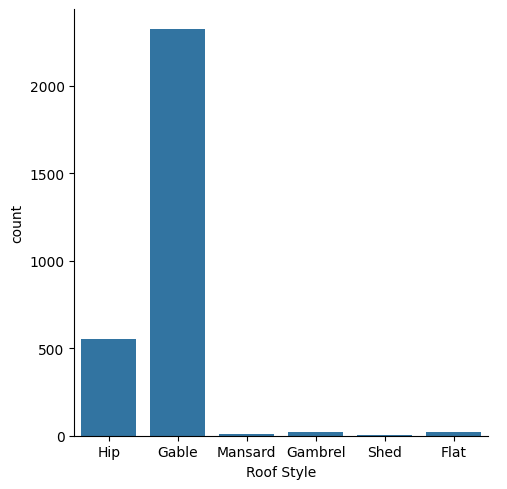

In [ ]:
sns.catplot(x="Roof Style", kind="count", data=housing)

<details>
<summary><strong>Solution</strong> (Click Here)</summary>
    &emsp; &emsp; <code>
 housing["Sale Condition"].value_counts()
</code>
</details>


## **Looking for Correlations**


Before proceeding with the data cleaning, it is useful to establish a correlation between the response variable (in our case the sale price) and other predictor variables, as some of them might not have any major impact in determining the price of the house and will not be used in the analysis.  There are many ways to discover correlation between the target variable and the rest of the features. Building pair plots, scatter plots, heat maps, and a correlation matrixes are the most common ones. Below, we will use the `corr()` function to list the top features based on the [pearson correlation coefficient](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) (measures how closely two sequences of numbers are correlated). Correlation coefficient can only be calculated on the numerical attributes (floats and integers), therefore, only the numeric attributes will be selected.


In [ ]:
hous_num = housing.select_dtypes(include = ['float64', 'int64'])
hous_num_corr = hous_num.corr()['SalePrice'][:-1] # -1 means that the latest row is SalePrice
top_features = hous_num_corr[abs(hous_num_corr) > 0.5].sort_values(ascending=False) #displays pearsons correlation coefficient greater than 0.5
print("There is {} strongly correlated values with SalePrice:\n{}".format(len(top_features), top_features))

There is 11 strongly correlated values with SalePrice:
Overall Qual      0.799226
Gr Liv Area       0.706791
Garage Cars       0.647891
Garage Area       0.640411
Total Bsmt SF     0.632270
1st Flr SF        0.621672
Year Built        0.558340
Full Bath         0.545339
Year Remod/Add    0.532664
Garage Yr Blt     0.526808
Mas Vnr Area      0.508277
Name: SalePrice, dtype: float64


Above, there are 11 features, with coefficients greater than 0.5, that are strongly correlated with the sale price.


Next, let's generate some par plots to visually inspect the correlation between some of these features and the target variable. We will use seaborns `sns.pairplot()` function for this analysis. Also, building pair plots is one of the possible ways to spot the outliers that might be present in the data.


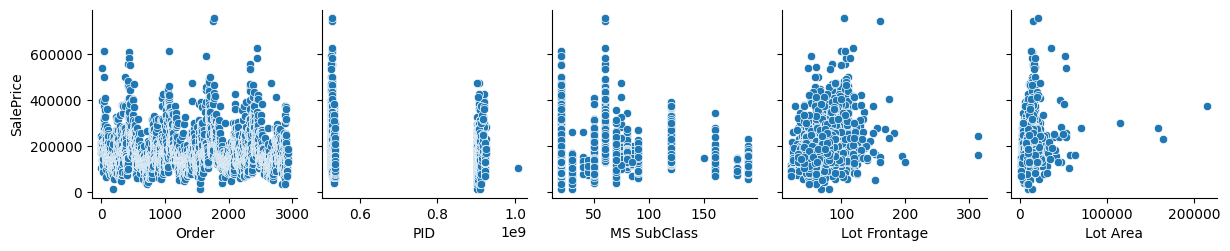

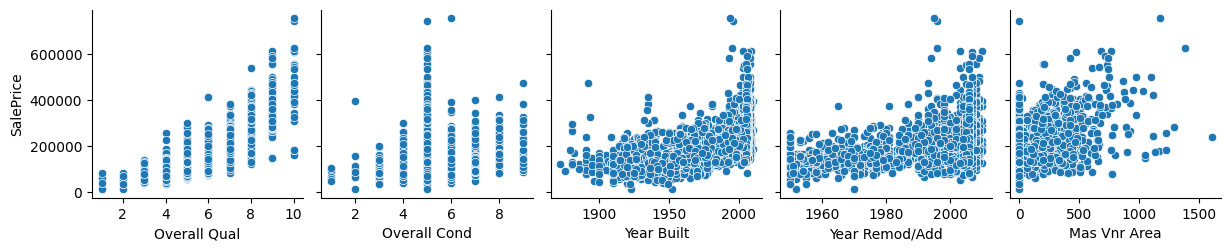

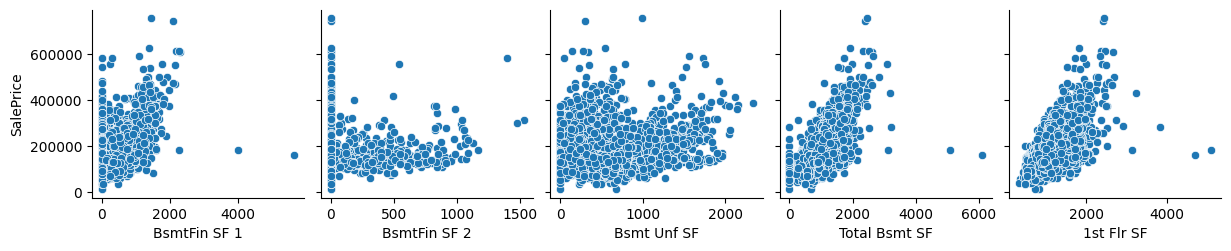

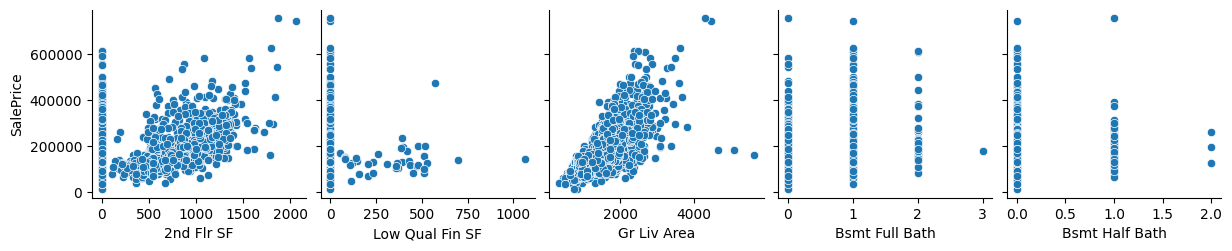

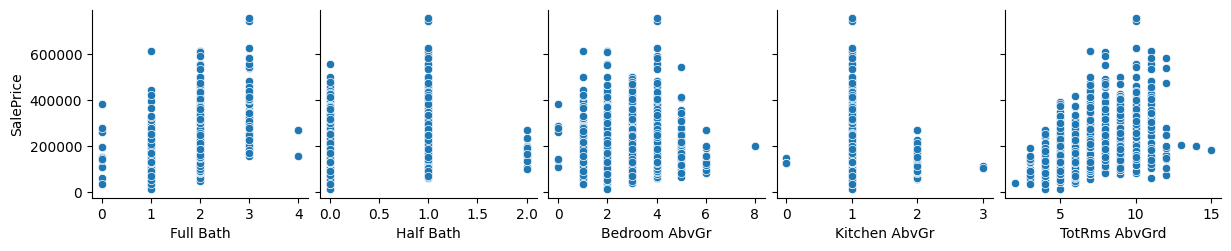

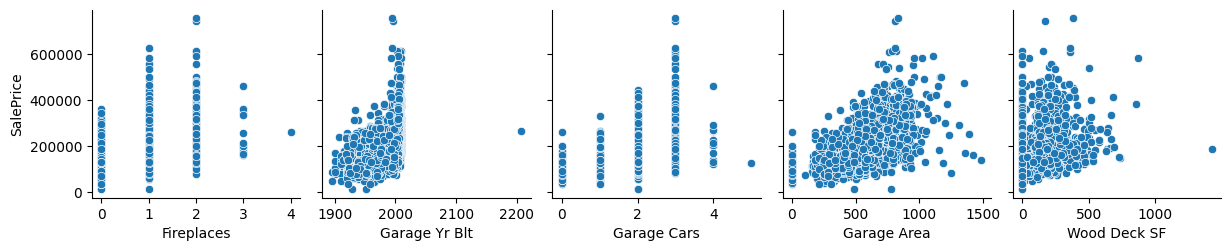

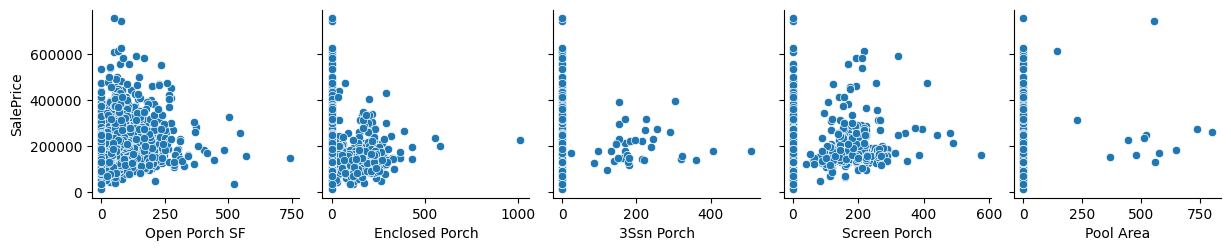

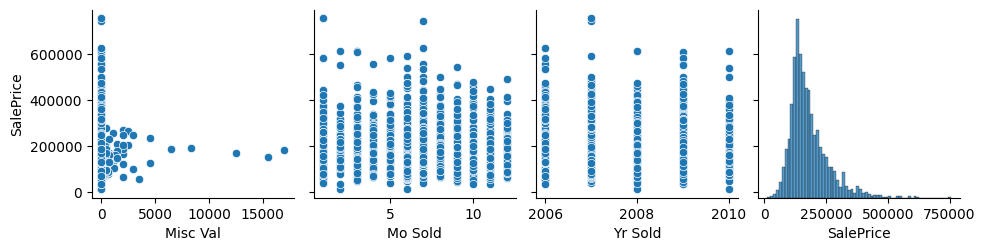

In [ ]:
for i in range(0, len(hous_num.columns), 5):
    sns.pairplot(data=hous_num,
                x_vars=hous_num.columns[i:i+5],
                y_vars=['SalePrice'])

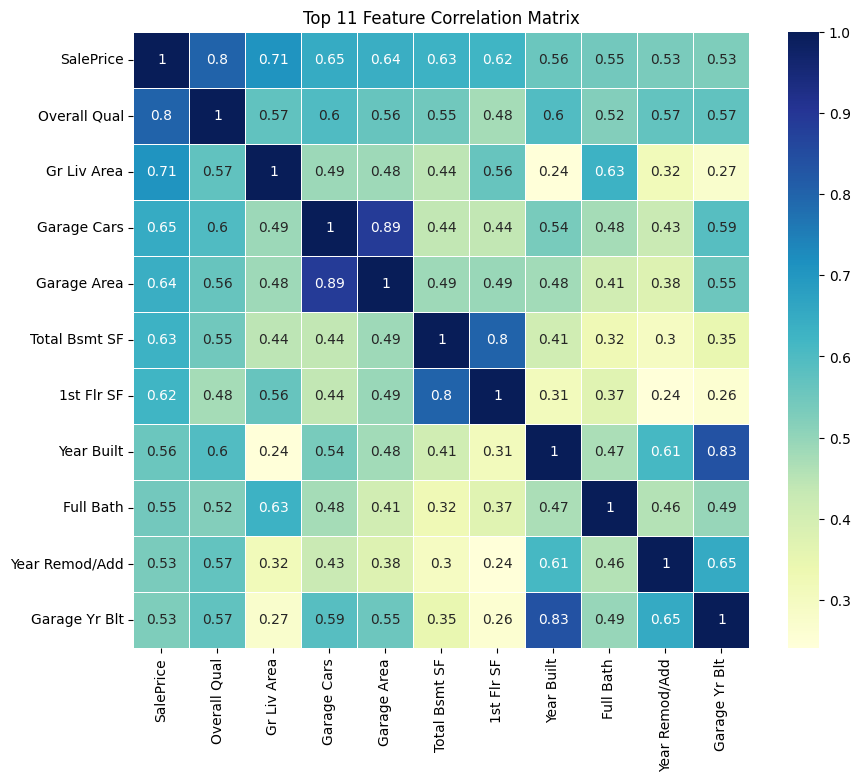

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute full correlation matrix
co_mtx = housing.corr(numeric_only=True)

# Choose target variable
target = 'SalePrice'

# Get top 11 features most correlated with the target
top_features = co_mtx[target].abs().sort_values(ascending=False).head(11).index

# Subset correlation matrix for those features
top_corr = housing[top_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr, cmap="YlGnBu", annot=True, linewidths=0.5, square=True)

plt.title('Top 11 Feature Correlation Matrix')
plt.show()


From Pearsons Correlation Coefficients and pair plots, we can draw some conclusions about the features that are most strongly correlated to the 'SalePrice'. They are: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', and others.


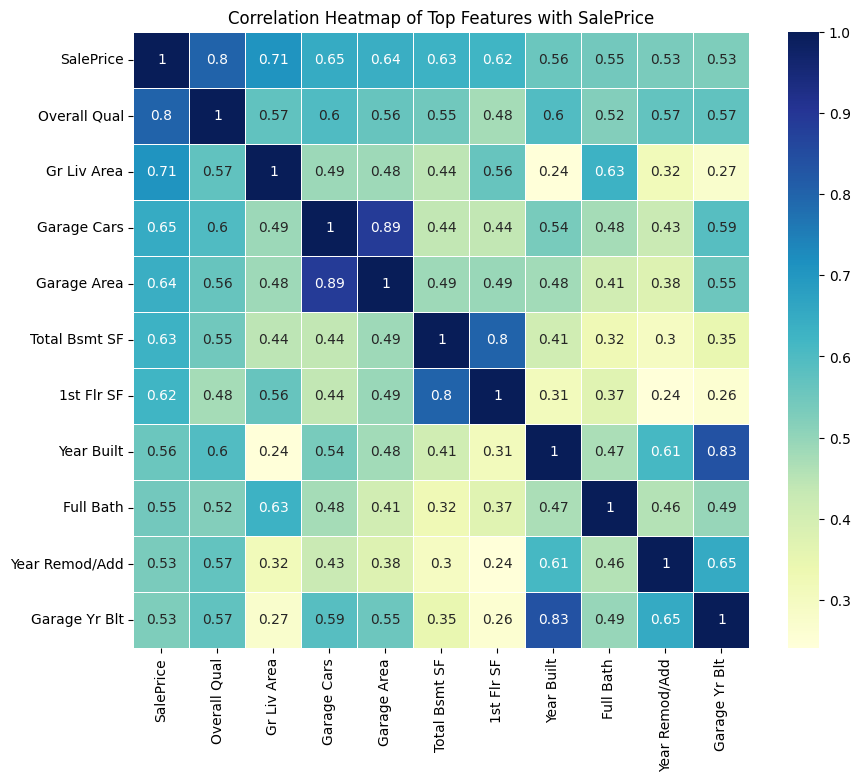

In [ ]:
# This code is simpler

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compute correlations with SalePrice only (numeric columns only)
correlations = housing.corr(numeric_only=True)['SalePrice'].abs()

# in general is: housing.corr(numeric_only=True)['TargetVariable'].abs()




# 2. Select the top 10 most correlated features + SalePrice itself
top_features = correlations.sort_values(ascending=False).head(11).index

# 3. Create a smaller DataFrame with just those features
top_data = housing[top_features]

# 4. Compute the correlation matrix of those top features
top_corr = top_data.corr()

# 5. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr, annot=True, cmap="YlGnBu", linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Top Features with SalePrice')
plt.show()


In [ ]:
# remember the original dataframe is:
housing.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000


In [ ]:
housing.select_dtypes(include = ['float64', 'int64'])

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,1,526301100,20,141.0,31770,6,5,1960,1960,112.0,...,210,62,0,0,0,0,0,5,2010,215000
1,1,526301100,20,141.0,31770,6,5,1960,1960,112.0,...,210,62,0,0,0,0,0,5,2010,215000
2,2,526350040,20,80.0,11622,5,6,1961,1961,0.0,...,140,0,0,0,120,0,0,6,2010,105000
3,3,526351010,20,81.0,14267,6,6,1958,1958,108.0,...,393,36,0,0,0,0,12500,6,2010,172000
4,4,526353030,20,93.0,11160,7,5,1968,1968,0.0,...,0,0,0,0,0,0,0,4,2010,244000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,2926,923275080,80,37.0,7937,6,6,1984,1984,0.0,...,120,0,0,0,0,0,0,3,2006,142500
2927,2927,923276100,20,NaN,8885,5,5,1983,1983,0.0,...,164,0,0,0,0,0,0,6,2006,131000
2928,2928,923400125,85,62.0,10441,5,5,1992,1992,0.0,...,80,32,0,0,0,0,700,7,2006,132000
2929,2929,924100070,20,77.0,10010,5,5,1974,1975,0.0,...,240,38,0,0,0,0,0,4,2006,170000


## **Log Transformation**


In this section, we are going to inspect whether our 'SalePrice' data are normally distributed. The assumption of the normal distribution must be met in order to perform any type of regression analysis. There are several ways to check for this assumption, however here, we will use the visual method, by plotting the 'SalePrice' distribution using the `distplot()` function from the `seaborn` library.


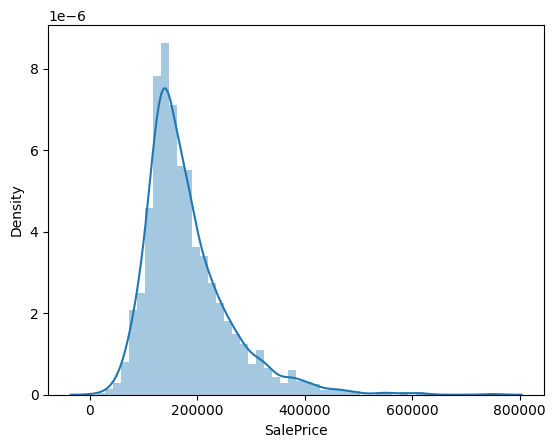

In [ ]:
sp_untransformed = sns.distplot(housing['SalePrice'])

As the plot shows, our 'SalePrice' deviates from the normal distribution. It has a longer tail to the right, so we call it a positive skew. In statistics *skewness* is a measure of asymmetry of the distribution. In addition to skewness, there is also a kurtosis, parameter which refers to the pointedness of a peak in the distribution curve. Both skewness and kurtosis are frequently used together to characterize the distribution of data.


Here, we can simply use the `skew()` function to calculate our skewness level of the `SalePrice`.


In [ ]:
print("Skewness: %f" % housing['SalePrice'].skew())

# %f prints a 6 decimal number
# % tells Python to insert the value into the string, replacing the %f

Skewness: 1.743222


In [ ]:
# Usinf f-string
print(f"Skewness: {housing['SalePrice'].skew():.6f}")


Skewness: 1.743222


The range of skewness for a fairly symmetrical bell curve distribution is between -0.5 and 0.5; moderate skewness is -0.5 to -1.0 and 0.5 to 1.0; and highly skewed distribution is < -1.0 and > 1.0. In our case, we have ~1.7, so it is considered  highly skewed data.

Now, we can try to transform our data, so it looks more normally distributed. We can use the `np.log()` function from the `numpy` library to perform log transform. This [documentation](https://numpy.org/doc/stable/reference/generated/numpy.log.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) contains more information about the numpy log transform.


In [ ]:
log_transformed = np.log(housing['SalePrice'])

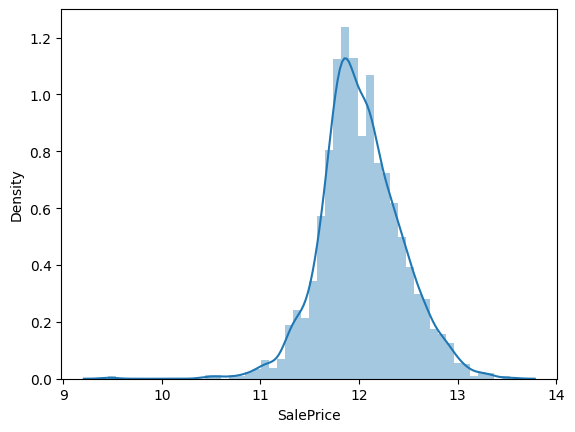

In [ ]:
sp_transformed = sns.distplot(log_transformed)

In [ ]:
print("Skewness: %f" % (log_transformed).skew())

Skewness: -0.015354


In [ ]:
print(f"Skewness: {log_transformed.skew():.6f}")

Skewness: -0.015354


As we can see, the log method transformed the 'SalePrice' distribution into a more symmetrical bell curve and the skewness level now is -0.01, well within the range.

There are other ways to correct for skewness of the data. For example, Square Root Transform (`np.sqrt`) and the Box-Cox Transform (`stats.boxcox` from the `scipy stats` library). To learn more about these two methods, please check out this [article](https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01).


Skewness: 0.884281


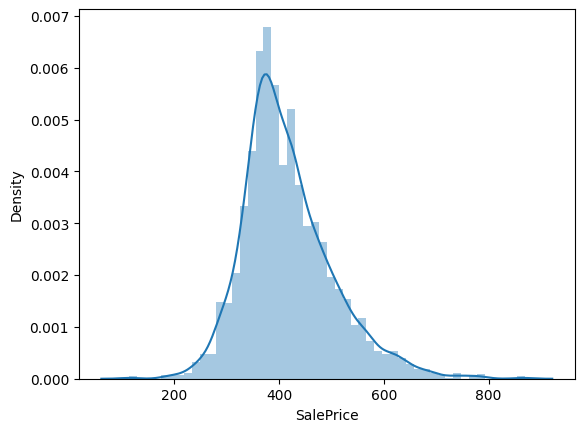

In [ ]:
sqrt_transformed= np.sqrt(housing['SalePrice'])
sns.distplot(sqrt_transformed)
print(f"Skewness: {sqrt_transformed.skew():.6f}")

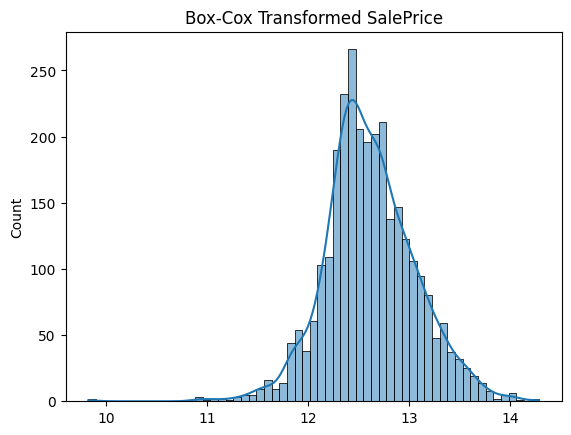

Skewness: 0.001596


In [ ]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Box-Cox transformation (returns: transformed data, lambda)
box_cox_transformed, fitted_lambda = stats.boxcox(housing['SalePrice'])

# Plot the transformed distribution
sns.histplot(box_cox_transformed, kde=True)  # Replaces deprecated sns.distplot
plt.title('Box-Cox Transformed SalePrice')
plt.show()

# Print skewness of the transformed data
print(f"Skewness: {pd.Series(box_cox_transformed).skew():.6f}")


## Exercise 2


In this exercise, visually inspect the 'Lot Area' feature. If there is any skewness present, apply log transform to make it more normally distributed.


<Axes: xlabel='Lot Area', ylabel='Density'>

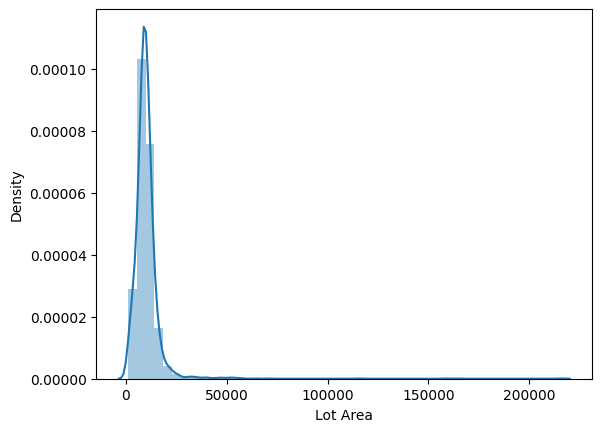

In [ ]:
sns.distplot(housing['Lot Area'])

In [ ]:
print("Skewness: %f" % housing['Lot Area'].skew())

Skewness: 12.778041


In [ ]:
print(f'Skewness: {housing["Lot Area"].skew():.6f}')

Skewness: 12.778041


In [ ]:
Lot_Area_log_transformed = np.log(housing['Lot Area'])

<Axes: xlabel='Lot Area', ylabel='Density'>

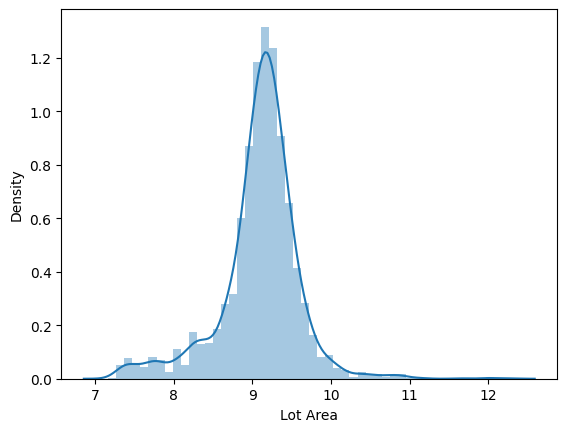

In [ ]:
sns.distplot(Lot_Area_log_transformed)

In [ ]:
print("Skewness: %f" % Lot_Area_log_transformed.skew())

Skewness: -0.494639


<details>
<summary><strong>Solution</strong> (Click Here)</summary>
    &emsp; &emsp; <code>
la_plot = sns.distplot(housing['Lot Area'])
print("Skewness: %f" % housing['Lot Area'].skew())
la_log = np.log(housing['Lot Area'])
print("Skewness: %f" % la_log.skew())

</code>
</details>


## **Handling the Duplicates**


In [ ]:
housing['PID']

,PID
0,526301100
1,526301100
2,526350040
3,526351010
4,526353030
...,...
2926,923275080
2927,923276100
2928,923400125
2929,924100070


As mentioned in the video, having duplicate values can effect our analysis, so it is good to check whether there are any duplicates in our data. We will use pandas `duplicated()` function and search by the 'PID' column, which contains a unique index number for each entry.


In [ ]:
duplicate = housing[housing.duplicated(['PID'])]
duplicate

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000


As we can see, there is one duplicate row in this dataset. To remove it, we can use pandas `drop_duplicates()` function. By default, it removes all duplicate rows based on all the columns.


In [ ]:
dup_removed = housing.drop_duplicates()
dup_removed

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2927,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2928,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2929,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


An alternative way to check if there are any duplicated Indexes in our dataset is using `index.is_unique` function.


In [ ]:
housing.index.is_unique

True

## Exercise 3


In this exercise try to remove duplicates on a specific column by setting the subset equal to the column that contains the duplicate, such as 'Order'.


In [ ]:
housing['Order']

,Order
0,1
1,1
2,2
3,3
4,4
...,...
2926,2926
2927,2927
2928,2928
2929,2929


In [ ]:
dup_removed_order= housing.drop_duplicates(subset=['Order'])


<details>
<summary><strong>Solution</strong> (Click Here)</summary>
    &emsp; &emsp; <code>
removed_sub = housing.drop_duplicates(subset=['Order'])
</code>
</details>


In [ ]:
dup_removed_order['Order']

,Order
0,1
2,2
3,3
4,4
5,5
...,...
2926,2926
2927,2927
2928,2928
2929,2929


## **Handling the Missing Values**


### Finding the Missing Values


For easier detection of missing values, pandas provides the `isna()`, `isnull()`, and `notna()` functions. For more information on pandas missing values please check out this [documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01).


To summarize all the missing values in our dataset, we will use `isnull()` function. Then, we will add them all up, by using `sum()` function, sort them with `sort_values()` function, and plot the first 20 columns (as the majority of our missing values fall within first 20 columns), using the `bar plot` function from the `matplotlib` library.


Text(0.5, 1.0, 'Total Missing Values')

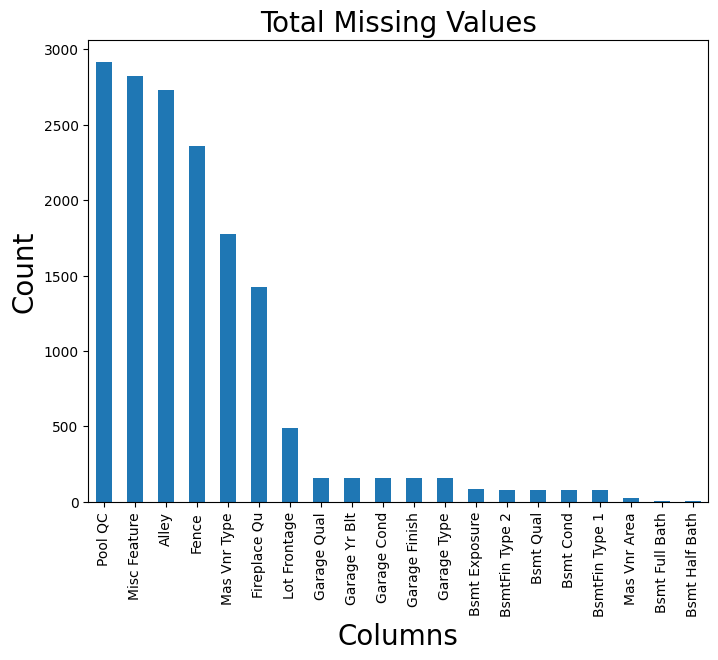

In [ ]:
total = housing.isnull().sum().sort_values(ascending=False)
total_select = total.head(20)
total_select.plot(kind="bar", figsize = (8,6), fontsize = 10)

plt.xlabel("Columns", fontsize = 20)
plt.ylabel("Count", fontsize = 20)
plt.title("Total Missing Values", fontsize = 20)

There are several options for dealing with missing values. We will use 'Lot Frontage' feature to analyze for missing values.


1. We can drop the missing values, using `dropna()` method.


In [ ]:
housing.dropna(subset=["Lot Frontage"])

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2925,923251180,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,131000
2926,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2928,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2929,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


Using this method, all the rows, containing null values in 'Lot Frontage' feature, for example, will be dropped.


2. We can drop the whole attribute (column), that contains missing values, using the `drop()` method.


In [ ]:
housing.drop("Lot Frontage", axis=1)

,Order,PID,MS SubClass,MS Zoning,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,526301100,20,RL,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,2926,923275080,80,RL,7937,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2927,2927,923276100,20,RL,8885,Pave,NaN,IR1,Low,AllPub,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2928,2928,923400125,85,RL,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2929,2929,924100070,20,RL,10010,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


Using this method, the entire column containing the null values will be dropped.


3. We can replace the missing values (zero, the mean, the median, etc.), using `fillna()` method.


In [ ]:
median = housing["Lot Frontage"].median()
median

68.0

In [ ]:
housing["Lot Frontage"].fillna(median, inplace = True)

In [ ]:
housing.tail()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2926,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2927,2927,923276100,20,RL,68.0,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2928,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2929,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000
2930,2930,924151050,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,188000


Index# 2927, containing a missing value in the "Lot Frontage", now has been replaced with the median value.


## Exercise 4


In this exercise, let's look at 'Mas Vnr Area' feature and replace the missing values with the mean value of that column.


In [ ]:
# Step 1. Calculate the median of the selected feature
median=housing['Mas Vnr Area'].median()

In [ ]:
# Step 2. Fill the NA values with the previously calculated median
housing['Mas Vnr Area'].fillna(median, inplace = True)

<details>
<summary><strong>Solution</strong> (Click Here)</summary>
    &emsp; &emsp; <code>
mean = housing["Mas Vnr Area"].mean()
housing["Mas Vnr Area"].fillna(mean, inplace = True)   
</code>
</details>


## **Feature Scaling**


One of the most important transformations we need to apply to our data is feature scaling.  There are two common ways to get all attributes to have the same scale: min-max scaling and standardization.

Min-max scaling (or normalization) is the simplest: values are shifted and rescaled so they end up ranging from 0 to 1. This is done by subtracting the min value and dividing by the max minus min.

Standardization is different: first it subtracts the mean value (so standardized values always have a zero mean), and then it divides by the standard deviation, so that the resulting distribution has unit variance.



Scikit-learn library provides `MinMaxScaler` for normalization and `StandardScaler` for standardization needs. For more information on `scikit-learn` [`MinMaxScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) and [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) please visit their respective documentation websites.


First, we will normalize our data.


In [ ]:
# Reminder, the dataframe hous_num is the one filtered with the numeric values
hous_num.head()


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,1,526301100,20,141.0,31770,6,5,1960,1960,112.0,...,210,62,0,0,0,0,0,5,2010,215000
1,1,526301100,20,141.0,31770,6,5,1960,1960,112.0,...,210,62,0,0,0,0,0,5,2010,215000
2,2,526350040,20,80.0,11622,5,6,1961,1961,0.0,...,140,0,0,0,120,0,0,6,2010,105000
3,3,526351010,20,81.0,14267,6,6,1958,1958,108.0,...,393,36,0,0,0,0,12500,6,2010,172000
4,4,526353030,20,93.0,11160,7,5,1968,1968,0.0,...,0,0,0,0,0,0,0,4,2010,244000


<Axes: xlabel='SalePrice', ylabel='Density'>

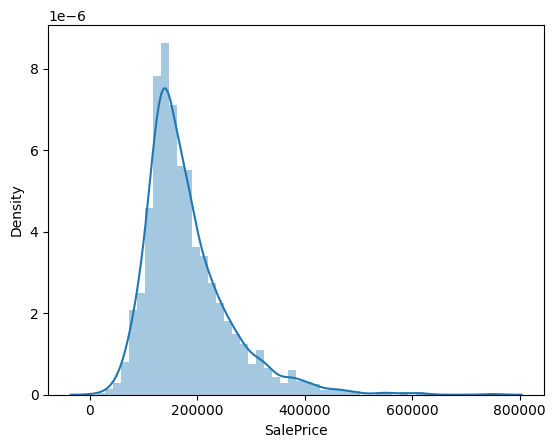

In [ ]:
sns.distplot(hous_num['SalePrice'])

In [ ]:
norm_data = MinMaxScaler().fit_transform(hous_num)
norm_data

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        3.63636364e-01, 1.00000000e+00, 2.72444089e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        3.63636364e-01, 1.00000000e+00, 2.72444089e-01],
       [3.41413452e-04, 1.01788895e-04, 0.00000000e+00, ...,
        4.54545455e-01, 1.00000000e+00, 1.24238256e-01],
       ...,
       [9.99317173e-01, 8.25914814e-01, 3.82352941e-01, ...,
        5.45454545e-01, 0.00000000e+00, 1.60616051e-01],
       [9.99658587e-01, 8.27370610e-01, 0.00000000e+00, ...,
        2.72727273e-01, 0.00000000e+00, 2.11814430e-01],
       [1.00000000e+00, 8.27476641e-01, 2.35294118e-01, ...,
        9.09090909e-01, 0.00000000e+00, 2.36066294e-01]])

Note the data is now a `ndarray`


In [ ]:
# So we can transform it into a dataframe


from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Normalize the data
scaler = MinMaxScaler()
norm_data = scaler.fit_transform(hous_num)

# Convert back to DataFrame
norm_df = pd.DataFrame(norm_data, columns=hous_num.columns, index=hous_num.index) # in columns and index we keep the original dataframe characteristics

# Now you can use norm_df like a normal DataFrame
norm_df.head()


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,0.000000,0.000000,0.0,0.410959,0.142420,0.555556,0.500,0.637681,0.166667,0.0700,...,0.147472,0.083558,0.0,0.0,0.000000,0.0,0.000000,0.363636,1.0,0.272444
1,0.000000,0.000000,0.0,0.410959,0.142420,0.555556,0.500,0.637681,0.166667,0.0700,...,0.147472,0.083558,0.0,0.0,0.000000,0.0,0.000000,0.363636,1.0,0.272444
2,0.000341,0.000102,0.0,0.202055,0.048246,0.444444,0.625,0.644928,0.183333,0.0000,...,0.098315,0.000000,0.0,0.0,0.208333,0.0,0.000000,0.454545,1.0,0.124238
3,0.000683,0.000104,0.0,0.205479,0.060609,0.555556,0.625,0.623188,0.133333,0.0675,...,0.275983,0.048518,0.0,0.0,0.000000,0.0,0.735294,0.454545,1.0,0.214509
4,0.001024,0.000108,0.0,0.246575,0.046087,0.666667,0.500,0.695652,0.300000,0.0000,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.272727,1.0,0.311517


<Axes: xlabel='SalePrice', ylabel='Density'>

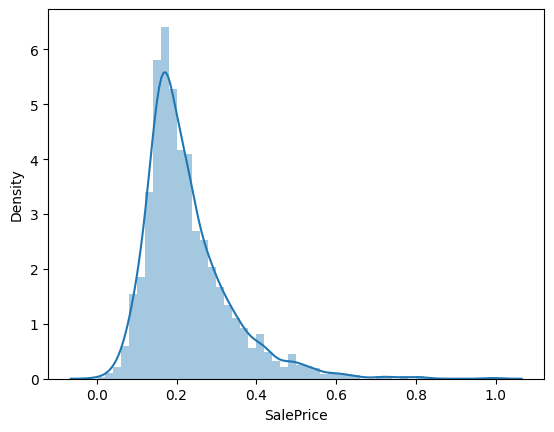

In [ ]:
# And let's see the effect in sales price
sns.distplot(norm_df['SalePrice'])

we can also standardize our data.


In [ ]:
scaled_data = StandardScaler().fit_transform(hous_num)
scaled_data

array([[-1.73027969, -0.99682434, -0.87674019, ..., -0.44796566,
         1.67740664,  0.4281423 ],
       [-1.73027969, -0.99682434, -0.87674019, ..., -0.44796566,
         1.67740664,  0.4281423 ],
       [-1.72909781, -0.99656498, -0.87674019, ..., -0.07945953,
         1.67740664, -0.94923488],
       ...,
       [ 1.729097  ,  1.10758639,  0.64804102, ...,  0.2890466 ,
        -1.36026952, -0.61115139],
       [ 1.73027889,  1.11129572, -0.87674019, ..., -0.81647179,
        -1.36026952, -0.13533019],
       [ 1.73146077,  1.11156589,  0.06158671, ...,  1.76307112,
        -1.36026952,  0.09005881]])

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Normalize the data
scaler2 = StandardScaler()
std_data = scaler2.fit_transform(hous_num)

# Convert back to DataFrame
std_df = pd.DataFrame(std_data, columns=hous_num.columns, index=hous_num.index) # in columns and index we keep the original dataframe characteristics

# Now you can use norm_df like a normal DataFrame
std_df.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,-1.730280,-0.996824,-0.87674,3.065953,2.740394,-0.067242,-0.506610,-0.375464,-1.163021,0.056407,...,0.919831,0.214370,-0.358769,-0.103117,-0.285302,-0.06302,-0.089407,-0.447966,1.677407,0.428142
1,-1.730280,-0.996824,-0.87674,3.065953,2.740394,-0.067242,-0.506610,-0.375464,-1.163021,0.056407,...,0.919831,0.214370,-0.358769,-0.103117,-0.285302,-0.06302,-0.089407,-0.447966,1.677407,0.428142
2,-1.729098,-0.996565,-0.87674,0.459214,0.185954,-0.776188,0.393313,-0.342391,-1.115078,-0.569113,...,0.365756,-0.704681,-0.358769,-0.103117,1.854918,-0.06302,-0.089407,-0.079460,1.677407,-0.949235
3,-1.727916,-0.996560,-0.87674,0.501947,0.521297,-0.067242,0.393313,-0.441611,-1.258908,0.034067,...,2.368342,-0.171038,-0.358769,-0.103117,-0.285302,-0.06302,21.989477,-0.079460,1.677407,-0.110287
4,-1.726734,-0.996549,-0.87674,1.014748,0.127380,0.641703,-0.506610,-0.110877,-0.779475,-0.569113,...,-0.742394,-0.704681,-0.358769,-0.103117,-0.285302,-0.06302,-0.089407,-0.816472,1.677407,0.791269


<Axes: xlabel='SalePrice', ylabel='Density'>

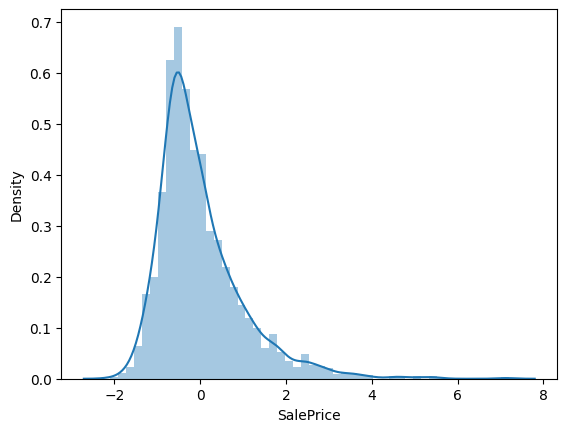

In [ ]:
sns.distplot(std_df['SalePrice'])

## Exercise 5


In this exercise, use `StandardScaler()` and `fit_transform()` functions to standardize the 'SalePrice' feature only.


In [ ]:
# Extract the column and convert it to a NumPy array
price = housing['SalePrice'].values.reshape(-1, 1)
# We need to convert housing['SalePrice'].values that leads to a numpy array
# but need to be reshaped to get a 2d array containing smaples and features

# Apply StandardScaler
scaled_price = StandardScaler().fit_transform(price)

<Axes: ylabel='Density'>

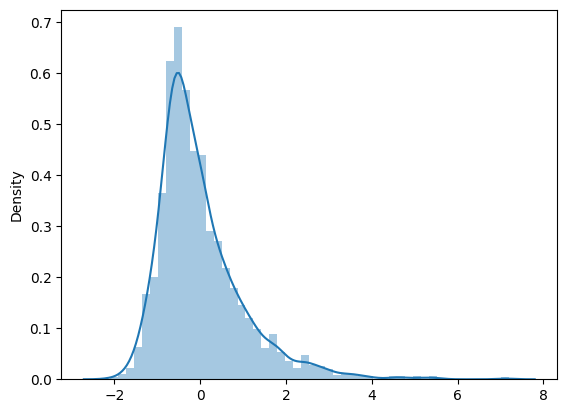

In [ ]:
sns.distplot(scaled_price)

In the previous plot we see the effect of using the standard scaler, so the values have zero mean.

<details>
<summary><strong>Solution</strong> (Click Here)</summary>
    &emsp; &emsp; <code>
scaled_sprice = StandardScaler().fit_transform(housing['SalePrice'][:,np.newaxis])
scaled_sprice
</code>
</details>



## **Handling the Outliers**


### Finding the Outliers


In statistics, an outlier is an observation point that is distant from other observations. An outlier can be due to some mistakes in data collection or recording, or due to natural high variability of data points. How to treat an outlier highly depends on our data or the type of analysis to be performed. Outliers can markedly affect our models and can be a valuable source of information, providing us insights about specific behaviours.

There are many ways to discover outliers in our data. We can do Uni-variate analysis (using one variable analysis) or Multi-variate analysis (using two or more variables). One of the simplest ways to detect an outlier is to inspect the data visually, by making box plots or scatter plots.


### Uni-variate Analysis


A box plot is a method for graphically depicting groups of numerical data through their quartiles. Box plots may also have lines extending vertically from the boxes (whiskers) indicating variability outside the upper and lower quartiles. Outliers may be plotted as individual points. To learn more about box plots please click [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01).


Here, we will use a box plot for the 'Lot Area' and the 'SalePrice' features.


<Axes: xlabel='Lot Area'>

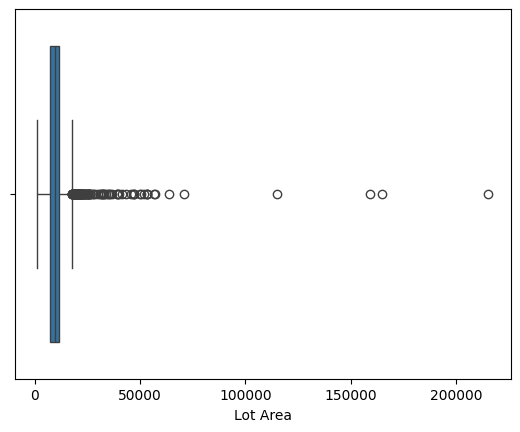

In [ ]:
sns.boxplot(x=housing['Lot Area'])

<Axes: xlabel='SalePrice'>

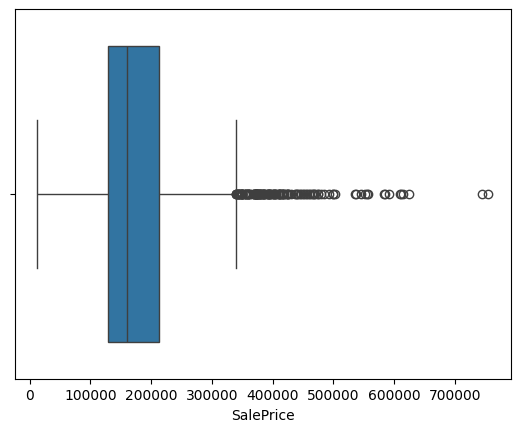

In [ ]:
sns.boxplot(x=housing['SalePrice'])

As we can see from these two plots, we have some points that are plotted outside the box plot area and that greatly deviate from the rest of the population. Whether to remove or keep them will greatly depend on the understanding of our data and the type of analysis to be performed. In this case, the points that are outside of our box plots in the 'Lot Area' and the 'Sale Price' might be the actual true data points and do not need to be removed.


### Bi-variate Analysis


Next, we will look at the bi-variate analysis of the two features, the sale price, 'SalePrice', and the ground living area, 'GrLivArea', and plot the scatter plot of the relationship between these two parameters.


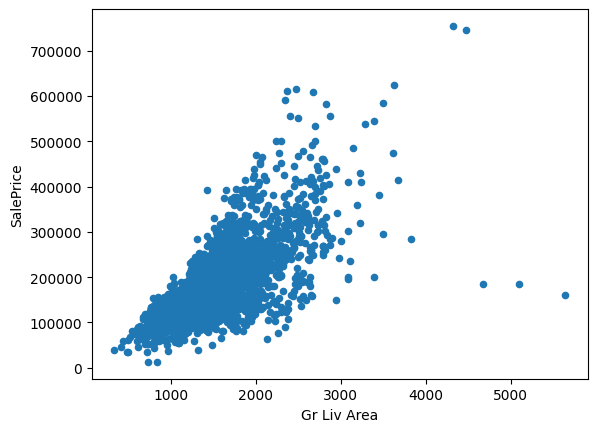

In [ ]:
price_area = housing.plot.scatter(x='Gr Liv Area',
                      y='SalePrice')

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

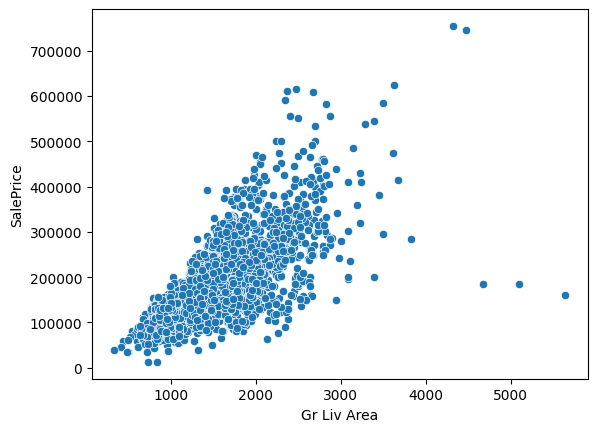

In [ ]:
# Alternatively...
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=housing)

From the above graph, there are two values above 5000 sq. ft. living area that deviate from the rest of the population and do not seem to follow the trend. It can be speculated why this is happening but for the purpose of this lab we can delete them.

The other two observations on the top are also deviating from the rest of the points but they also seem to be following the trend, so, perhaps, they can be kept.


### Deleting the Outliers


First, we will sort all of our 'Gr Liv Area' values and select only the last two.


In [ ]:
housing.sort_values(by = 'Gr Liv Area', ascending = False)[:2]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1499,1499,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2181,2181,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850


Now we will use the pandas `drop()` function to remove these two rows.


In [ ]:
outliers_dropped = housing.drop(housing.index[[1499,2181]])

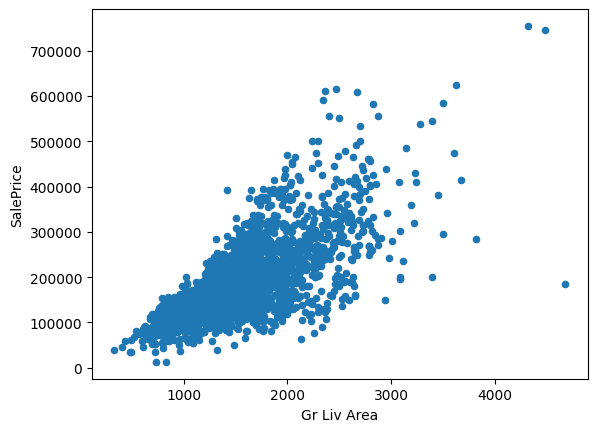

In [ ]:
new_plot = outliers_dropped.plot.scatter(x='Gr Liv Area',
                                         y='SalePrice')

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

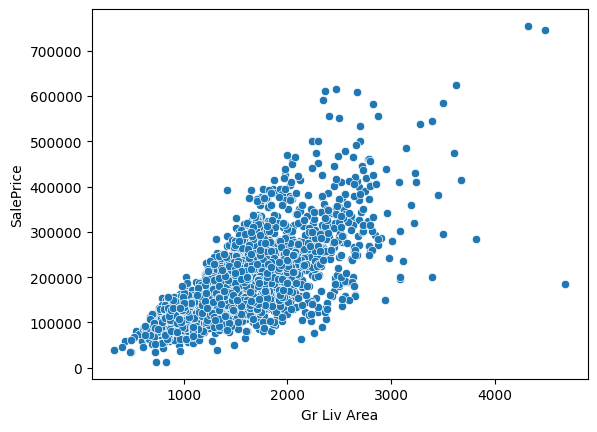

In [ ]:
# or with seaborb
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=outliers_dropped)

In [ ]:
from scipy import stats
import pandas as pd

# Calculate z-scores and sort the top 10 highest values
z_scores = stats.zscore(housing['Gr Liv Area'], nan_policy='omit')  # handle NaNs safely
z_scores_series = pd.Series(z_scores, index=housing.index)

top_10_Gr_Liv_area = z_scores_series.sort_values(ascending=False).head(10)
print(top_10_Gr_Liv_area)


1499    8.196894
2181    7.114464
2182    6.285327
1761    5.889557
1768    5.572942
1498    4.591433
2738    4.298564
2446    4.209516
2667    4.171918
2451    3.958202
dtype: float64


As you can see, we do not have the last two points of the 'Gr Liv Area' anymore.


## Exercise 6


In this exercise, determine whether there are any outliers in the 'Lot Area' feature. You can either plot the box plot for the 'Lot Area', perform a bi-variate analysis by making a scatter plot between the 'SalePrice' and the 'Lot Area', or use the Z-score analysis. If there re any outliers, remove them from the dataset.


<Axes: xlabel='Lot Area'>

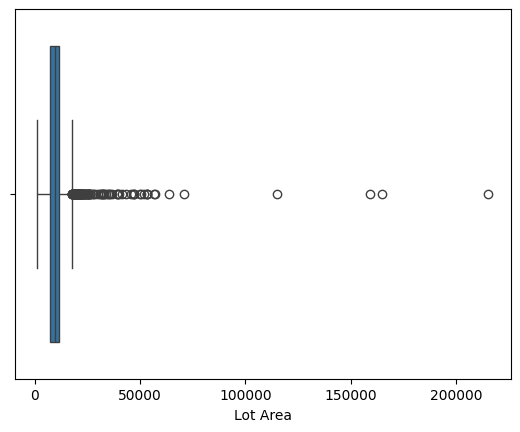

In [ ]:
# Alternative 1 using the boxplot
sns.boxplot(x=housing['Lot Area'])

<Axes: xlabel='Lot Area', ylabel='SalePrice'>

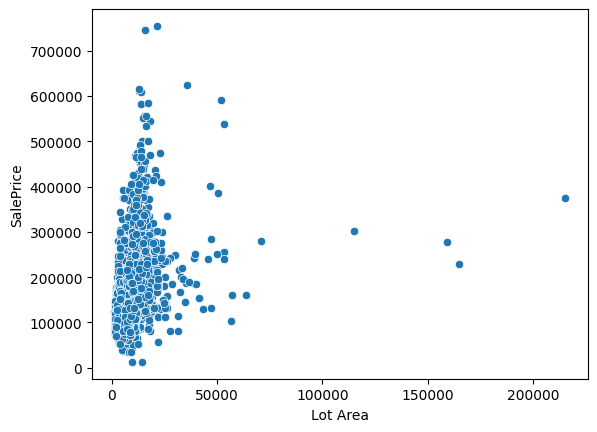

In [ ]:
#Alternative 2 using bi-variate analysis
sns.scatterplot(x='Lot Area', y='SalePrice', data=housing)

In [ ]:
from scipy import stats
import pandas as pd

# Calculate z-scores and sort the top 10 highest values
z_scores = stats.zscore(housing['Lot Area'], nan_policy='omit')  # handle NaNs safely
z_scores_series = pd.Series(z_scores, index=housing.index)

top_10_lot_area = z_scores_series.sort_values(ascending=False).head(10)
print(top_10_lot_area)


957     26.002051
1571    19.588693
2116    18.871096
2072    13.311500
2767     7.683821
1499     6.812309
315      5.964506
1611     5.888436
16       5.495913
1403     5.460794
dtype: float64


In [ ]:
clean_df=housing.drop(housing.index[[957]])

<Axes: xlabel='Lot Area', ylabel='SalePrice'>

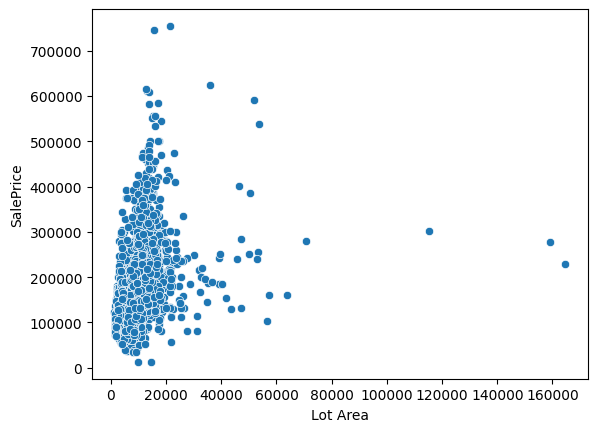

In [ ]:
sns.scatterplot(x='Lot Area', y='SalePrice', data=clean_df)

<details>
<summary><strong>Solution</strong> (Click Here)</summary>
    &emsp; &emsp; <code>
sns.boxplot(x=housing['Lot Area'])
price_lot = housing.plot.scatter(x='Lot Area', y='SalePrice')   
housing['Lot_Area_Stats'] = stats.zscore(housing['Lot Area'])
housing[['Lot Area','Lot_Area_Stats']].describe().round(3)
housing.sort_values(by = 'Lot Area', ascending = False)[:1]
lot_area_rem = housing.drop(housing.index[[957]])
</code>
</details>


<details>
<summary><strong>Answer</strong> (Click Here)</summary>
    &emsp; &emsp; <code>
There seems to be one outlier, the very last point in the 'Lot Area' is too far from the rest of the group. Also, according to the Z-score, the standard deviation of that point exceeds the threshhold of 3.
</code>
</details>


In [ ]:
# Also using a filter o threshold

import pandas as pd
from scipy import stats

# Calculate z-scores for 'Lot Area'
z_scores = stats.zscore(housing['Lot Area'])

# Get a boolean mask for z-scores <= 3 (keep only those rows)
mask = abs(z_scores) <= 3

# Apply the mask to filter the DataFrame
cleaned_housing = housing[mask]

# Check shape before/after if you want
print("Original size:", housing.shape)
print("Cleaned size:", cleaned_housing.shape)


Original size: (2931, 82)
Cleaned size: (2902, 82)


<Axes: xlabel='Lot Area', ylabel='SalePrice'>

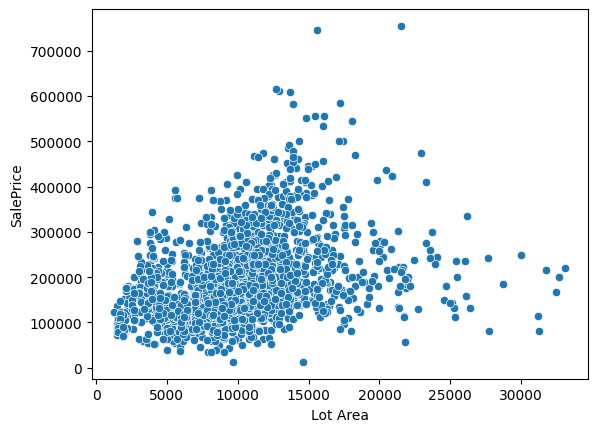

In [ ]:
# see another plot
sns.scatterplot(x='Lot Area', y='SalePrice', data=cleaned_housing)

## Z-score Analysis


Z-score is another way to identify outliers mathematically. Z-score is the signed number of standard deviations by which the value of an observation or data point is above the mean value of what is being observed or measured. In another words, Z-score is the value that quantifies relationship between a data point and a standard deviation and mean values of a group of points. Data points which are too far from zero will be treated as the outliers. In most of the cases, a threshold of 3 or -3 is used. For example, if the Z-score value is greater than or less than 3 or -3 standard deviations respectively, that data point will be identified as a outlier.

To learn more about Z-score, please visit this [Wikipedia](https://en.wikipedia.org/wiki/Standard_score?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) site.


Below, we are using Z-score function from `scipy` library to detect the outliers in our 'Low Qual Fin SF' parameter. To learn more about `scipy.stats`, please visit this [link](https://docs.scipy.org/doc/scipy/reference/tutorial/stats.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01).


In [ ]:
housing['LQFSF_Stats'] = stats.zscore(housing['Low Qual Fin SF']) # here we calculate the z'score on each row and create a new column into the dataframe
housing[['Low Qual Fin SF','LQFSF_Stats']].describe().round(3) # Here we describe the original and z-scored version of the same column

,Low Qual Fin SF,LQFSF_Stats
count,2931.000,2931.000
mean,4.675,-0.000
std,46.303,1.000
min,0.000,-0.101
25%,0.000,-0.101
50%,0.000,-0.101
75%,0.000,-0.101
max,1064.000,22.882


A z-score tells you how many standard deviations a value is from the mean of the column.
Formula:

$z= \frac{x-μ}{\sigma}$



The scaled results show a mean of 0.000 and a standard deviation of 1.000, indicating that the transformed values fit the z-scale model. The max value of 22.882 is further proof of the presence of outliers, as it falls well above the z-score limit of +3.


# Congratulations! - You have completed the lab


## Author


[Svitlana Kramar](www.linkedin.com/in/svitlana-kramar)


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By            | Change Description                   |
| ----------------- | ------- | --------------------- | ------------------------------------ |
| 2021-11-30        | 0.1     | Svitlana       | Added the Log Transformation section |
| 2022-01-18        | 0.2     | Svitlana       | Added the Introduction               |


In [ ]:
housing.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,LQFSF_Stats
count,2931.000000,2.931000e+03,2931.000000,2931.000000,2931.000000,2931.000000,2931.000000,2931.000000,2931.000000,2931.000000,...,2931.000000,2931.000000,2931.000000,2931.000000,2931.000000,2931.000000,2931.000000,2931.000000,2931.000000,2.931000e+03
mean,1465.000341,7.144003e+08,57.374616,69.044353,10155.298874,6.094848,5.562948,1971.352439,1984.258274,101.100648,...,47.538383,23.003753,2.591607,15.996588,2.242579,50.617878,6.215626,2007.791198,180807.729785,-2.545445e-17
std,846.250554,1.887306e+08,42.636341,21.364193,7888.789128,1.410786,1.111396,30.240926,20.861542,178.604172,...,67.472412,64.129522,25.137086,56.078577,35.591130,566.248407,2.714122,1.317021,79875.557267,1.000171e+00
min,1.000000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000,-1.009875e-01
25%,732.500000,5.284770e+08,20.000000,60.000000,7440.500000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000,-1.009875e-01
50%,1465.000000,5.354532e+08,50.000000,68.000000,9439.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000,-1.009875e-01
75%,2197.500000,9.071811e+08,70.000000,78.000000,11556.000000,7.000000,6.000000,2001.000000,2004.000000,162.500000,...,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000,-1.009875e-01
max,2930.000000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000,2.288216e+01
